# Kaggle Qwen2.5 3B GRPO Run

Use this notebook from the Kaggle-backed VS Code kernel. It runs the complementary 3B Unsloth GRPO experiment while the campus server runs the default 1.5B job.

## 1. GPU Check

Expected on Kaggle: two T4 GPUs. If this cell does not show T4s, the notebook is not attached to the Kaggle kernel.

In [9]:
!nvidia-smi

Sat Apr 25 22:20:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Bootstrap Kaggle Working Directory And Repo

The Kaggle kernel cannot see your local laptop path. This section resets the remote kernel to `/kaggle/working`, then clones or updates the pushed `round2-redshift` branch. Run these cells even if a previous `%cd` failed.


In [10]:
import os
from pathlib import Path

Path("/kaggle/working").mkdir(parents=True, exist_ok=True)
os.chdir("/kaggle/working")
print("cwd:", os.getcwd())


cwd: /kaggle/working


In [11]:
import os, shutil, subprocess, time
from pathlib import Path

REPO_URL = "https://github.com/srimanreddy4/MetaHackathon-R2"
BRANCH = "accel-attack"
WORKDIR = Path("/kaggle/working/MetaHackathon-R2")

os.chdir("/kaggle/working")
if (WORKDIR / ".git").exists():
    os.chdir(WORKDIR)
    subprocess.run(["git", "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "checkout", BRANCH], check=True)
    subprocess.run(["git", "pull", "--ff-only", "origin", BRANCH], check=True)
else:
    if WORKDIR.exists():
        backup = WORKDIR.with_name(f"{WORKDIR.name}.bak.{int(time.time())}")
        shutil.move(str(WORKDIR), str(backup))
        print("Moved non-git existing directory to", backup)
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, str(WORKDIR)], check=True)
    os.chdir(WORKDIR)

print("cwd:", os.getcwd())
subprocess.run(["git", "log", "--oneline", "-5"], check=True)


From https://github.com/srimanreddy4/MetaHackathon-R2
 * branch            accel-attack -> FETCH_HEAD
Already on 'accel-attack'


M	curriculum_results/buffer.json
Your branch is up to date with 'origin/accel-attack'.
Already up to date.
cwd: /kaggle/working/MetaHackathon-R2
b293f56 fixed buffer size
9c8272c pull and fix
2bb62a1 Merge branch 'round2-redshift' of https://github.com/srimanreddy4/MetaHackathon-R2 into accel-attack
7fc73d4 .
34016dc non verbose


From https://github.com/srimanreddy4/MetaHackathon-R2
 * branch            accel-attack -> FETCH_HEAD


CompletedProcess(args=['git', 'log', '--oneline', '-5'], returncode=0)

In [12]:
%cd /kaggle/working/MetaHackathon-R2
%env PYTHONPATH=src:scripts
!python - <<'PY'
import os
from pathlib import Path
print("cwd=", Path.cwd())
print("PYTHONPATH=", os.environ.get("PYTHONPATH"))
print("repo exists=", Path("src/oncallenv").exists())



/kaggle/working
env: PYTHONPATH=src:scripts
/bin/bash: line 1: warning: here-document at line 1 delimited by end-of-file (wanted `PY')
cwd= /kaggle/working/MetaHackathon-R2
PYTHONPATH= src:scripts
repo exists= True


## 3. Install Dependencies

Run the normal install first. If Kaggle has a PyTorch/CUDA dependency conflict, use the fallback cell after it.

In [13]:
!python -m pip install -U pip setuptools wheel
!python -m pip install -r requirements.txt
!python -m pip install -r requirements-llm.txt

In [6]:
# Fallback install if the previous cell fails:
# !python -m pip install -U transformers datasets accelerate trl peft bitsandbytes unsloth

## 4. Verify Environment

Expected: `21 passed` and OpenEnv validation OK.

In [14]:
!bash scripts/run_kaggle_qwen3b_grpo.sh verify

........................                                                 [100%]
=============================== warnings summary ===============================
../../../usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64
  /usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
    prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

../../../usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85
../../../usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85
../../../usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85
../../../usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85
../../../usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85
../../../usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85
  /usr/local/l

## 5. Small 3B Smoke Run

This is intentionally small. Continue only if it writes `training_results/unsloth_grpo_qwen3b_smoke/summary.json`.

In [8]:
!bash scripts/run_kaggle_qwen3b_grpo.sh smoke

^C
Traceback (most recent call last):
  File "/kaggle/working/MetaHackathon-R2/scripts/train_unsloth_grpo.py", line 22, in <module>
    from oncallenv import OnCallRedShiftEnv
  File "/kaggle/working/MetaHackathon-R2/src/oncallenv/__init__.py", line 3, in <module>
    from oncallenv.core.env import OnCallRedShiftEnv
  File "/kaggle/working/MetaHackathon-R2/src/oncallenv/core/__init__.py", line 3, in <module>
    from oncallenv.core.env import OnCallRedShiftEnv
  File "/kaggle/working/MetaHackathon-R2/src/oncallenv/core/env.py", line 10, in <module>
    from openenv.core import Environment
  File "/usr/local/lib/python3.12/dist-packages/openenv/core/__init__.py", line 14, in <module>
    from . import env_server
  File "/usr/local/lib/python3.12/dist-packages/openenv/core/env_server/__init__.py", line 74, in <module>
    from .web_interface import create_web_interface_app, WebInterfaceManager
  File "/usr/local/lib/python3.12/dist-packages/openenv/core/env_server/web_interface.py", line

In [ ]:
!cat training_results/unsloth_grpo_qwen3b_smoke/summary.json

## 6. Main Kaggle 3B Run

This is the main complementary run: Qwen2.5 3B, 160 curriculum tasks, 600 GRPO steps.

In [15]:
!bash scripts/run_kaggle_qwen3b_grpo.sh easy-main

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
2026-04-25 22:20:55.312748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777155655.335244     989 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777155655.342905     989 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777155655.362791     989 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777155655.362829     989 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17

In [18]:
!cat training_results/unsloth_grpo_qwen3b_easy/summary.json
!bash scripts/run_kaggle_qwen3b_grpo.sh summary

{
  "model_name": "unsloth/Qwen2.5-3B-Instruct-bnb-4bit",
  "duration_sec": 22912.60270524025,
  "max_steps": 300,
  "num_train_tasks": 36,
  "num_eval_tasks": 32,
  "curriculum_buffer": "curriculum_results/buffer.json",
  "reward_mode": "easy",
  "prompt_mode": "easy",
  "prompt_variants": 3,
  "baseline_mean_reward": 0.6381434027777778,
  "trained_mean_reward": 0.8918864583333335,
  "adapter_dir": "training_results/unsloth_grpo_qwen3b_easy/adapter",
  "dataset_path": "training_results/unsloth_grpo_qwen3b_easy/dataset.jsonl",
  "trainable_parameter_report": {
    "total": 1728606208,
    "trainable": 29933568,
    "lora_tensors": 504
  },
  "dynamic_curriculum": true,
  "curriculum_update_every": 40,
  "difficulty_source": "feedback",
  "rollouts_per_candidate": 3,
  "curriculum_updates": [
    {
      "updated_tasks": 11,
      "added_tasks": 0
    },
    {
      "updated_tasks": 12,
      "added_tasks": 0
    },
    {
      "updated_tasks": 11,
      "added_tasks": 0
    },
    {
  

In [ ]:
!ls -lh training_results/unsloth_grpo_qwen3b_kaggle
!ls -lh training_results/unsloth_grpo_qwen3b_kaggle/checkpoint-300
!cat training_results/unsloth_grpo_qwen3b_kaggle/checkpoint-300/trainer_state.json | tail -80


total 256K
-rw-r--r-- 1 root root  27K Apr 25 03:25 baseline_generations.json
drwxr-xr-x 2 root root 4.0K Apr 25 04:51 checkpoint-100
drwxr-xr-x 2 root root 4.0K Apr 25 06:17 checkpoint-200
drwxr-xr-x 2 root root 4.0K Apr 25 07:43 checkpoint-300
-rw-r--r-- 1 root root 211K Apr 25 03:20 dataset.jsonl
-rw-r--r-- 1 root root 2.1K Apr 25 07:43 README.md
total 189M
-rw-r--r-- 1 root root 1.2K Apr 25 07:43 adapter_config.json
-rw-r--r-- 1 root root 115M Apr 25 07:43 adapter_model.safetensors
-rw-r--r-- 1 root root  605 Apr 25 07:43 added_tokens.json
-rw-r--r-- 1 root root 2.5K Apr 25 07:43 chat_template.jinja
-rw-r--r-- 1 root root 1.6M Apr 25 07:43 merges.txt
-rw-r--r-- 1 root root  59M Apr 25 07:43 optimizer.pt
-rw-r--r-- 1 root root 5.2K Apr 25 07:43 README.md
-rw-r--r-- 1 root root  15K Apr 25 07:43 rng_state.pth
-rw-r--r-- 1 root root 1.4K Apr 25 07:43 scaler.pt
-rw-r--r-- 1 root root 1.5K Apr 25 07:43 scheduler.pt
-rw-r--r-- 1 root root  614 Apr 25 07:43 special_tokens_map.json
-rw-r--

## 7. Optional Extended Run

Run this only if the main 600-step job is stable and Kaggle time remains.

In [ ]:
# !bash scripts/run_kaggle_qwen3b_grpo.sh long

## 8. OOM Fallback

If the 3B smoke run OOMs, run this 1.5B ablation instead. It still gives a Kaggle portability result.

In [ ]:
# !bash scripts/run_kaggle_qwen3b_grpo.sh fallback-1b5

## 9. Archive Outputs

Download `/kaggle/working/qwen3b_grpo_results.tar.gz` from Kaggle outputs.

In [19]:
!bash scripts/run_kaggle_qwen3b_grpo.sh archive

tar: training_results/unsloth_grpo_kaggle_ablation: Cannot stat: No such file or directory
tar: Exiting with failure status due to previous errors


📊 Training Reward & Health Plots:


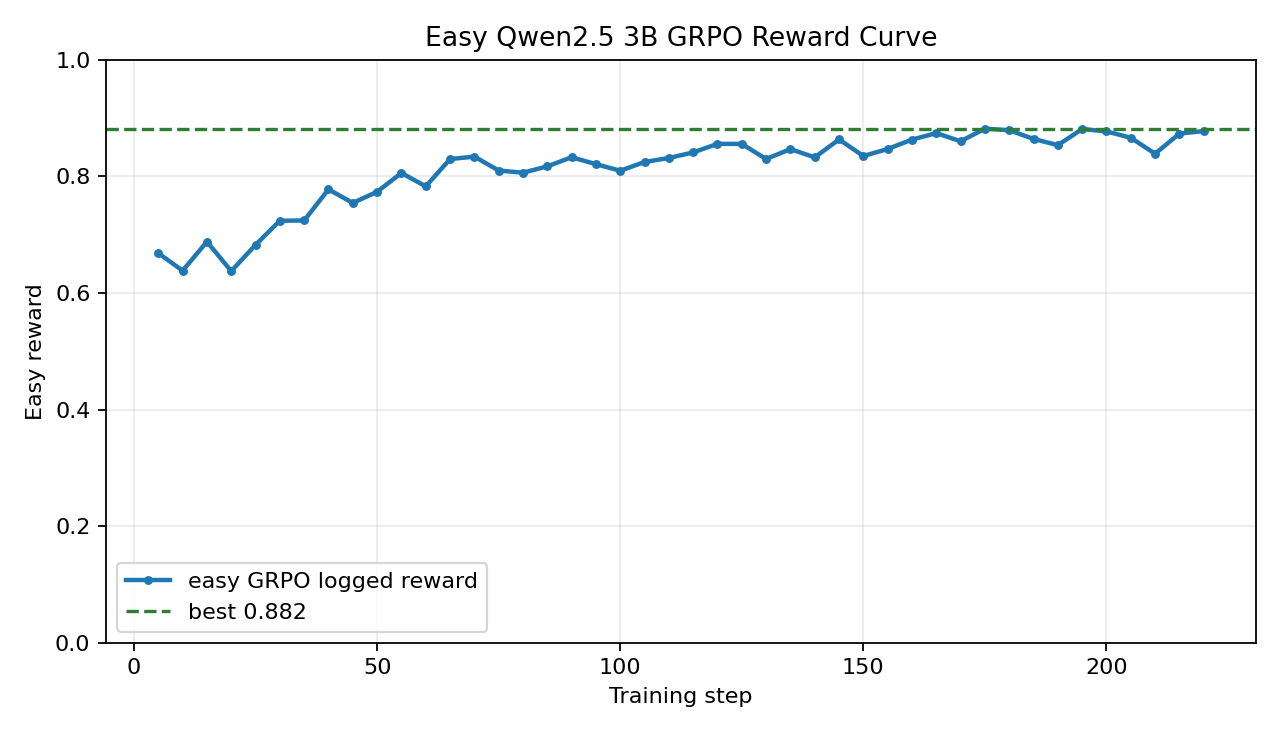

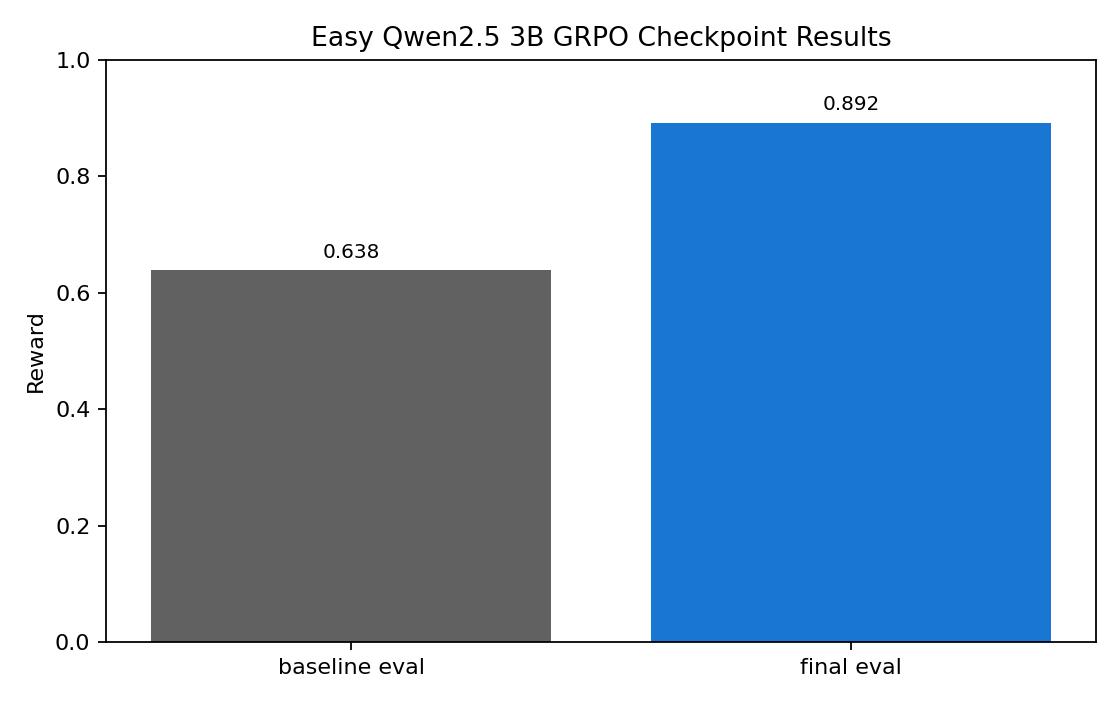

In [52]:
import os
from IPython.display import Image, display

# The summary script generates these 3 standard plots based on the prefix it was given
plot_files = [
    "docs/plots/easy_grpo_qwen3b_reward_curve.png",        # Reward over steps
    "docs/plots/easy_grpo_qwen3b_checkpoint_results.png",  # Step-by-step eval comparisons
]

print("📊 Training Reward & Health Plots:")
print("="*40)

for plot in plot_files:
    if os.path.exists(plot):
        display(Image(filename=plot))
        print("\n")
    else:
        print(f"⚠️ Plot not found: {plot} (Make sure the trainer logged enough steps!)")


In [23]:
!ls training_results/unsloth_grpo_qwen3b_easy

adapter			   checkpoint-200  dataset.jsonl
baseline_generations.json  checkpoint-250  README.md
checkpoint-100		   checkpoint-300  summary.json
checkpoint-150		   checkpoint-50   trained_generations.json


In [24]:
!zip -r unsloth_grpo_qwen3b_easy.zip training_results/unsloth_grpo_qwen3b_easy

  adding: training_results/unsloth_grpo_qwen3b_easy/ (stored 0%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/ (stored 0%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/merges.txt (deflated 57%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/scaler.pt (deflated 64%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/special_tokens_map.json (deflated 69%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/added_tokens.json (deflated 67%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/vocab.json (deflated 61%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/README.md (deflated 65%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/training_args.bin (deflated 53%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/adapter_config.json (deflated 57%)
  adding: training_results/unsloth_grpo_qwen3b_easy/checkpoint-200/tokenizer.

In [25]:
!cat training_results/unsloth_grpo_qwen3b_easy/trained_generations.json

{
  "mean_reward": 0.8918864583333335,
  "scores": {
    "seed_easy_memory_leak": 0.9363135416666667,
    "evolved_0001_823796c06b": 0.8620427083333335,
    "evolved_0002_516316e0e5": 0.9363135416666667,
    "evolved_0003_ce9349227d": 0.8495427083333336,
    "seed_dns_misconfiguration": 0.9370427083333334,
    "evolved_0004_63fa0016a2": 0.8613135416666668,
    "evolved_0000_048610d10c": 0.8620427083333335,
    "seed_cache_stampede": 0.8627718750000002,
    "seed_cert_expiry": 0.8620427083333335,
    "seed_replica_lag": 0.9363135416666667,
    "seed_http_503_loop": 0.8613135416666668,
    "evolved_0005_c1de71f632": 0.935584375
  },
  "generations": {
    "seed_easy_memory_leak": {
      "completion": "<actions>\n  kubectl_logs payment-service -c payment-service -n OnCallEnvRedShift\n  promql_query \"rate(payment_service_errors{job='payment-service'}[1m])\" -n OnCallEnvRedShift\n  kubectl_rollout_restart payment-service -n OnCallEnvRedShift\n  declare_resolved\n</actions> </actions>",
  

In [26]:
!bash scripts/run_kaggle_qwen3b_grpo.sh easy-summary

{
  "model_name": "unsloth/Qwen2.5-3B-Instruct-bnb-4bit",
  "duration_sec": 22912.60270524025,
  "max_steps": 300,
  "num_train_tasks": 36,
  "num_eval_tasks": 32,
  "curriculum_buffer": "curriculum_results/buffer.json",
  "reward_mode": "easy",
  "prompt_mode": "easy",
  "prompt_variants": 3,
  "baseline_mean_reward": 0.6381434027777778,
  "trained_mean_reward": 0.8918864583333335,
  "adapter_dir": "training_results/unsloth_grpo_qwen3b_easy/adapter",
  "dataset_path": "training_results/unsloth_grpo_qwen3b_easy/dataset.jsonl",
  "trainable_parameter_report": {
    "total": 1728606208,
    "trainable": 29933568,
    "lora_tensors": 504
  },
  "dynamic_curriculum": true,
  "curriculum_update_every": 40,
  "difficulty_source": "feedback",
  "rollouts_per_candidate": 3,
  "curriculum_updates": [
    {
      "updated_tasks": 11,
      "added_tasks": 0
    },
    {
      "updated_tasks": 12,
      "added_tasks": 0
    },
    {
      "updated_tasks": 11,
      "added_tasks": 0
    },
    {
  

📊 Training Progress Plots:


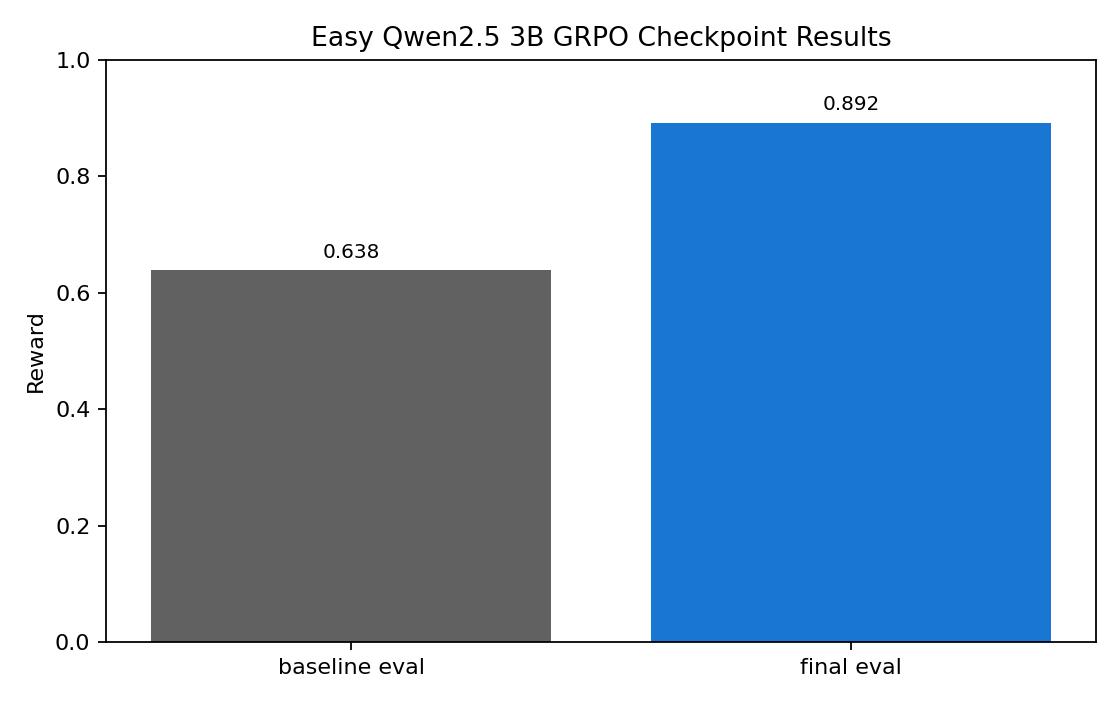

In [31]:
import os
from IPython.display import Image, display

# We grab the main reward curve and the completion health plots
plot_files = [
    "docs/plots/easy_grpo_qwen3b_checkpoint_results.png"
]

print("📊 Training Progress Plots:")
print("="*40)
for plot in plot_files:
    if os.path.exists(plot):
        display(Image(filename=plot))
        print("\n")
    else:
        print(f"⚠️ Plot not found: {plot} (Make sure a checkpoint has been saved first!)")


In [29]:
!ls docs/plots/

autocurriculum_diversity.png
autocurriculum_solve_rate_hist.png
baseline_scores.json
baseline_vs_trained.png
curriculum_policy_baseline_vs_trained.png
curriculum_policy_training_curve.png
easy_grpo_qwen3b_checkpoint_results.png
easy_grpo_qwen3b_completion_health.png
easy_grpo_qwen3b_reward_curve.png
gpu_policy_baseline_vs_trained.png
gpu_policy_training_curve.png
remote_baseline_vs_scripted.png
schema_drift_ablation.png
training_curve.png


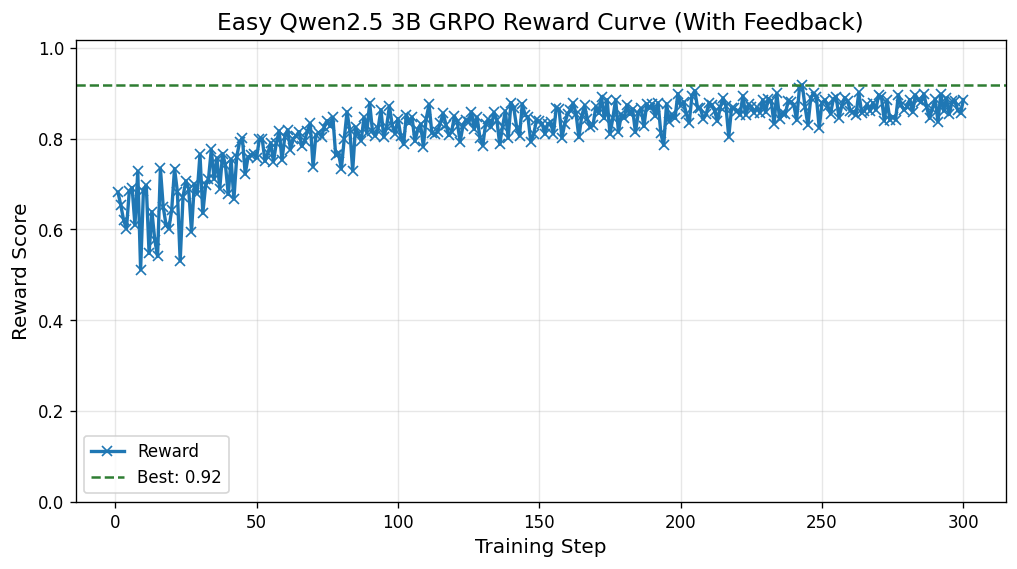

In [35]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Find the latest checkpoint folder
run_dir = Path("training_results/unsloth_grpo_qwen3b_easy")
checkpoints = sorted(run_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))

if not checkpoints:
    print("No checkpoints found yet!")
else:
    latest = checkpoints[-1]
    state_path = latest / "trainer_state.json"
    
    if not state_path.exists():
        print(f"Missing {state_path}")
    else:
        # Load the raw logged data from the HuggingFace Trainer
        state = json.loads(state_path.read_text())
        log_history = state.get("log_history", [])
        
        # Extract steps and rewards
        steps = []
        rewards = []
        for row in log_history:
            # We look for either GRPO reward format
            reward = row.get("reward", row.get("rewards/redshift_reward/mean"))
            if reward is not None:
                steps.append(row.get("step"))
                rewards.append(reward)
                
        if not rewards:
            print(f"No reward logs found in {state_path} yet.")
        else:
            # Plot the Reward Curve
            plt.figure(figsize=(10, 5), dpi=120)
            plt.plot(steps, rewards, marker="x", linewidth=2, color="#1f77b4", label="Reward")
            plt.axhline(max(rewards), color="#2E7D32", linestyle="--", linewidth=1.5, label=f"Best: {max(rewards):.2f}")
            plt.title("Easy Qwen2.5 3B GRPO Reward Curve (With Feedback)", fontsize=14)
            plt.xlabel("Training Step", fontsize=12)
            plt.ylabel("Reward Score", fontsize=12)
            plt.ylim(0, max(1.0, max(rewards) + 0.1))
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()


In [36]:
!ls /kaggle/input/datasets/birudugaddasrivibhav/qwen-runs/checkpoint-200

adapter_config.json	   README.md		    tokenizer.json
adapter_model.safetensors  rng_state.pth	    trainer_state.json
added_tokens.json	   scaler.pt		    training_args.bin
chat_template.jinja	   scheduler.pt		    vocab.json
merges.txt		   special_tokens_map.json
optimizer.pt		   tokenizer_config.json


In [42]:
import os
import sys
import json
import torch
import pandas as pd
from pathlib import Path
from peft import PeftModel
from unsloth import FastLanguageModel
from tqdm.auto import tqdm  # <-- Progress Bar!

# ==========================================
# 0. SETUP PATHS FOR IMPORTS
# ==========================================
repo_dir = "/kaggle/working/MetaHackathon-R2"
os.chdir(repo_dir) 

if f"{repo_dir}/src" not in sys.path:
    sys.path.insert(0, f"{repo_dir}/src")
if f"{repo_dir}/scripts" not in sys.path:
    sys.path.insert(0, f"{repo_dir}/scripts")

from train_unsloth_grpo import parse_commands, rollout_reward

# ==========================================
# 1. DEFINE YOUR MODELS HERE
# ==========================================
MODEL_A = "/kaggle/working/MetaHackathon-R2/training_results/unsloth_grpo_qwen3b_easy/checkpoint-300"
MODEL_B = "/kaggle/input/datasets/birudugaddasrivibhav/qwen-runs/checkpoint-200" # <-- Put your uploaded Kaggle dataset model path here later!

models_to_test = [path for path in [MODEL_A, MODEL_B] if path]

# ==========================================
# 2. LOAD 24 CONSISTENT EVALUATION TASKS
# ==========================================
dataset_path = Path("/kaggle/working/MetaHackathon-R2/training_results/unsloth_grpo_qwen3b_easy/dataset.jsonl")
eval_rows = [json.loads(line) for line in dataset_path.read_text().splitlines() if line.strip()][:24]
print(f"Loaded {len(eval_rows)} evaluation tasks.")

# ==========================================
# 3. LOAD THE BASE MODEL (ONCE)
# ==========================================
BASE_MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
print(f"\nLoading heavy base model {BASE_MODEL_NAME} into GPU...")
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_NAME,
    max_seq_length=1280,
    load_in_4bit=True,
    fast_inference=False,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ==========================================
# 4. RUN SIDE-BY-SIDE INFERENCE EVALUATION
# ==========================================
comparison_results = {}

for idx, adapter_path in enumerate(models_to_test):
    print(f"\n[{idx+1}/{len(models_to_test)}] Mounting Model: {adapter_path}")
    active_model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=False)
    FastLanguageModel.for_inference(active_model)
    active_model.eval()
    
    scores = []
    
    # ===== TQDM PROGRESS BAR LOOP =====
    for row in tqdm(eval_rows, desc=f"Evaluating Model {idx+1}"):
        inputs = tokenizer(row["prompt"], return_tensors="pt").to(active_model.device)
        with torch.no_grad():
            output_ids = active_model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        completion = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
        
        # Ship completion to Red Shift simulator to test!
        reward = rollout_reward(
            task_id=row["task_id"],
            completion=completion,
            root_service=row["root_service"],
            root_category=row["root_category"],
            required=row.get("required", []),
            reward_mode="easy"
        )
        scores.append(reward)
        
    mean_reward = sum(scores) / len(scores) if scores else 0.0
    comparison_results[adapter_path] = mean_reward
    print(f"✅ Model Score: {mean_reward:.3f}")
    
    # Clear the specific adapter from GPU memory so the next one can fit
    del active_model
    torch.cuda.empty_cache()

# ==========================================
# 5. DISPLAY THE WINNER 
# ==========================================
print("\n" + "="*40)
print("🏆 FINAL MODEL COMPARISON 🏆")
print("="*40)
df = pd.DataFrame(list(comparison_results.items()), columns=["Model Path", "Inference Reward Score"])
display(df)


Loaded 24 evaluation tasks.

Loading heavy base model unsloth/Qwen2.5-3B-Instruct-bnb-4bit into GPU...
==((====))==  Unsloth 2025.11.1: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

[1/2] Mounting Model: /kaggle/working/MetaHackathon-R2/training_results/unsloth_grpo_qwen3b_easy/checkpoint-300


Evaluating Model 1:   0%|          | 0/24 [00:00<?, ?it/s]

✅ Model Score: 0.905

[2/2] Mounting Model: /kaggle/input/datasets/birudugaddasrivibhav/qwen-runs/checkpoint-200


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Evaluating Model 2:   0%|          | 0/24 [00:00<?, ?it/s]

✅ Model Score: 0.872

🏆 FINAL MODEL COMPARISON 🏆


,Model Path,Inference Reward Score
0,/kaggle/working/MetaHackathon-R2/training_resu...,0.904781
1,/kaggle/input/datasets/birudugaddasrivibhav/qw...,0.871650


Loaded 24 evaluation routines.

[+] Cold-Booting Base Model into GPU for 'Feedback'...
==((====))==  Unsloth 2025.11.1: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
[-] Mounting Adapter: /kaggle/working/MetaHackathon-R2/training_results/unsloth_grpo_qwen3b_easy/checkpoint-300...


Scoring Feedback:   0%|          | 0/24 [00:00<?, ?it/s]

🗑️ Wiping Feedback from GPU Memory...

[+] Cold-Booting Base Model into GPU for 'No Feedback'...
==((====))==  Unsloth 2025.11.1: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
[-] Mounting Adapter: /kaggle/input/datasets/birudugaddasrivibhav/qwen-runs/checkpoint-200...


Scoring No Feedback:   0%|          | 0/24 [00:00<?, ?it/s]

🗑️ Wiping No Feedback from GPU Memory...

🏆 OVERALL MEAN REWARDS 🏆


,Model,Reward
0,Feedback,0.904781
1,No Feedback,0.871650


/tmp/ipykernel_877/1645467856.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mean_scores, x="Model", y="Reward", palette=["#27AE60", "#7F8C8D"])


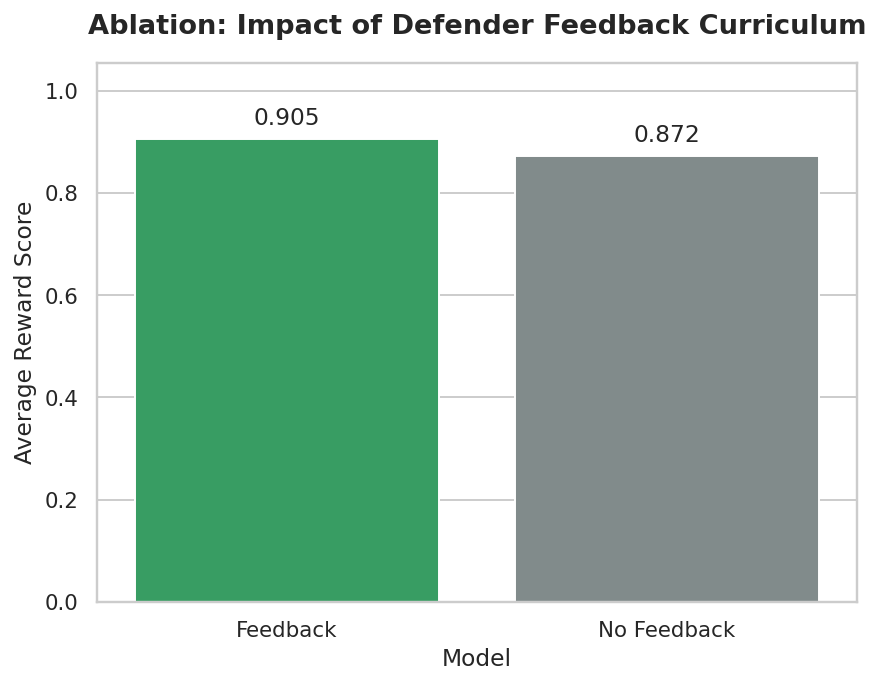

/tmp/ipykernel_877/1645467856.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Reward", y="Model", palette=["#A9DFBF", "#D5DBDB"], width=0.5)


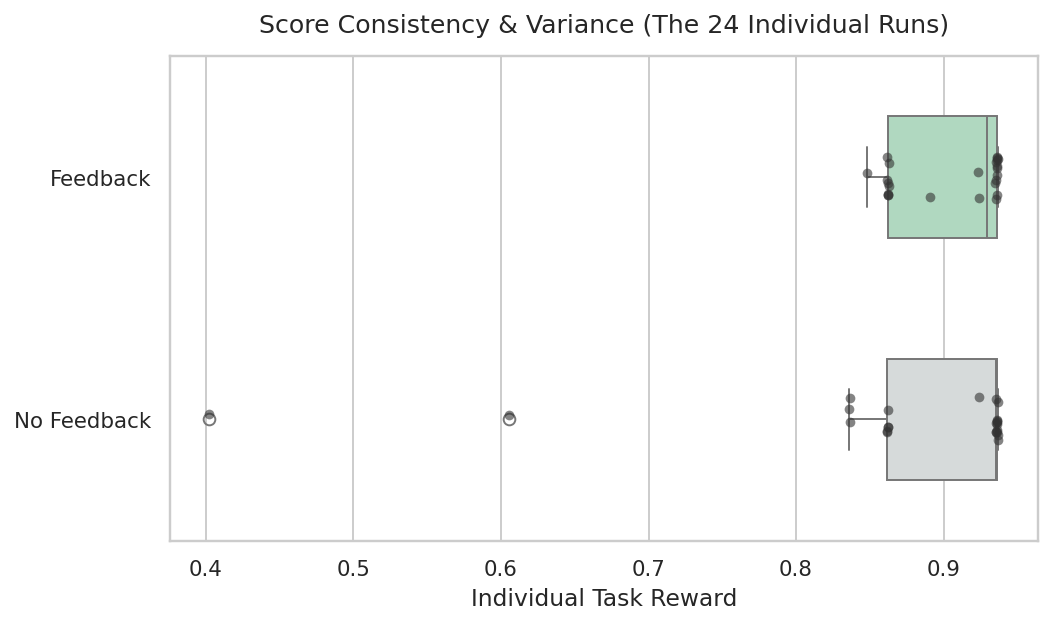

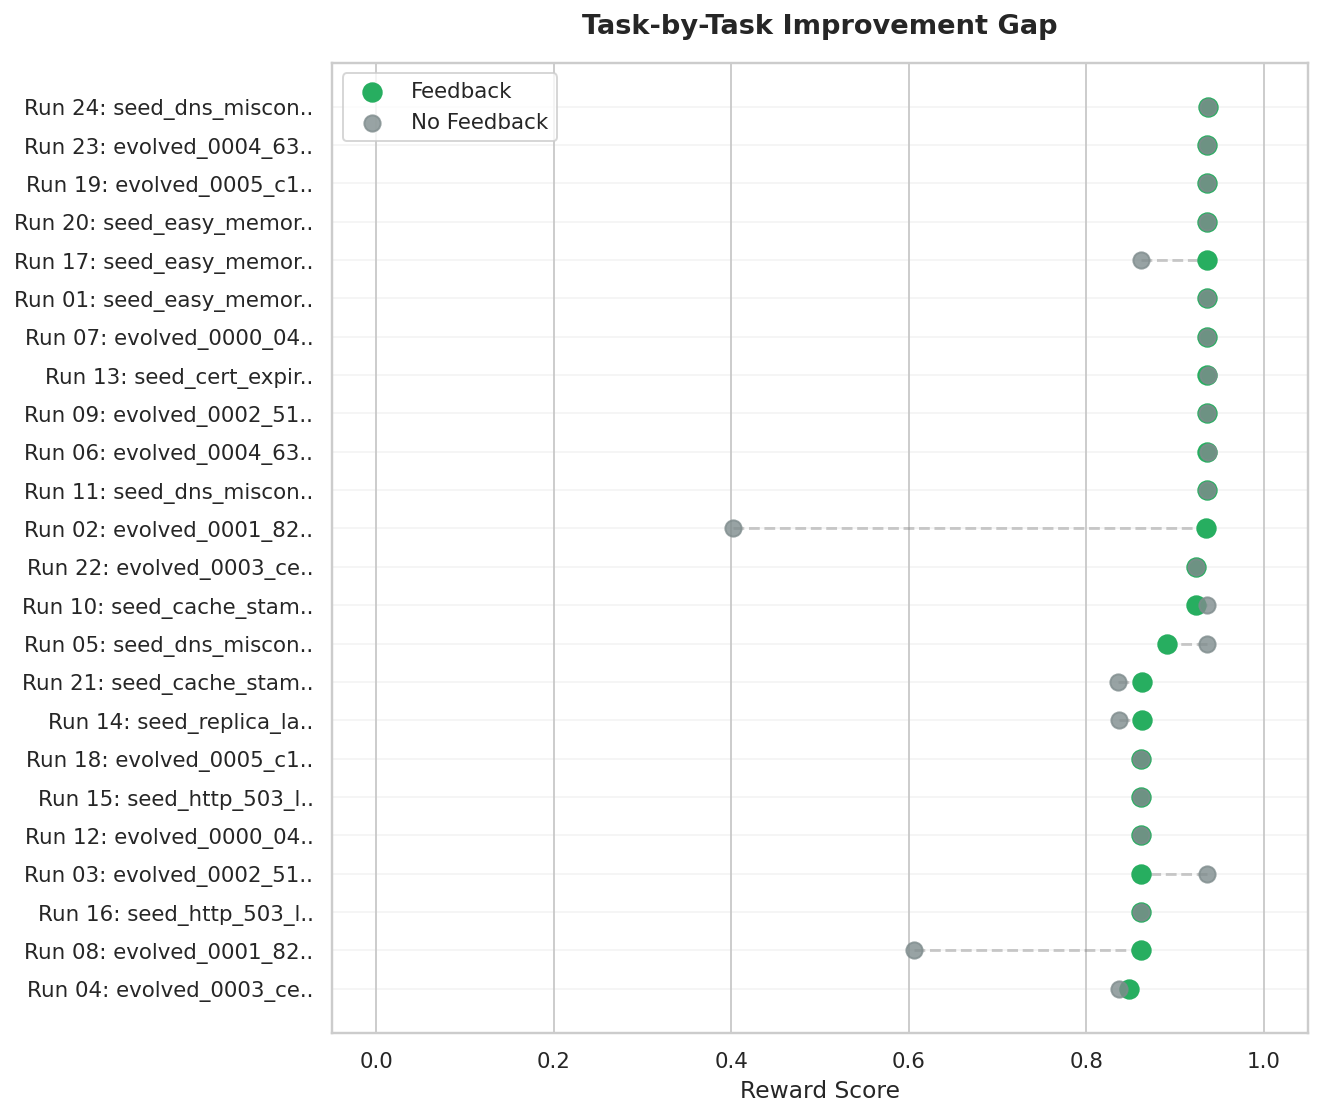

In [45]:
import os
import sys
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from peft import PeftModel
from unsloth import FastLanguageModel
from tqdm.auto import tqdm

# Setup beautiful matplotlib typography and aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 140

# ==========================================
# 0. SETUP IMPORTS 
# ==========================================
repo_dir = "/kaggle/working/MetaHackathon-R2"
os.chdir(repo_dir) 

if f"{repo_dir}/src" not in sys.path: sys.path.insert(0, f"{repo_dir}/src")
if f"{repo_dir}/scripts" not in sys.path: sys.path.insert(0, f"{repo_dir}/scripts")

from train_unsloth_grpo import rollout_reward

# ==========================================
# 1. SETUP THE ABLATION MODELS
# ==========================================
# We give them clean readable names for the plots!
MODEL_DICT = {
    "Feedback": "/kaggle/working/MetaHackathon-R2/training_results/unsloth_grpo_qwen3b_easy/checkpoint-300",
    "No Feedback": "/kaggle/input/datasets/birudugaddasrivibhav/qwen-runs/checkpoint-200"
}
models_to_test = {name: path for name, path in MODEL_DICT.items() if path}

# Load the 24 consistent testing tasks
dataset_path = Path("training_results/unsloth_grpo_qwen3b_easy/dataset.jsonl")
eval_rows = [json.loads(line) for line in dataset_path.read_text().splitlines() if line.strip()][:24]
print(f"Loaded {len(eval_rows)} evaluation routines.")

# ==========================================
# 2. RUN THE EXPERIMENT
# ==========================================
all_results = []
BASE_MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"

for model_name, adapter_path in models_to_test.items():
    print(f"\n[+] Cold-Booting Base Model into GPU for '{model_name}'...")
    base_model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL_NAME, max_seq_length=1280, load_in_4bit=True, fast_inference=False,
    )
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
    
    print(f"[-] Mounting Adapter: {adapter_path}...")
    active_model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=False)
    FastLanguageModel.for_inference(active_model)
    active_model.eval()
    
    for eval_idx, row in tqdm(enumerate(eval_rows), desc=f"Scoring {model_name}", total=len(eval_rows)):
        inputs = tokenizer(row["prompt"], return_tensors="pt").to(active_model.device)
        with torch.no_grad():
            output_ids = active_model.generate(**inputs, max_new_tokens=256, do_sample=False, pad_token_id=tokenizer.eos_token_id)
        completion = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
        
        reward = rollout_reward(
            task_id=row["task_id"], completion=completion, root_service=row["root_service"],
            root_category=row["root_category"], required=row.get("required", []), reward_mode="easy"
        )
        
        # Give each task a physically unique identifier for Pandas to pivot safely!
        unique_id = f"Run {eval_idx+1:02d}: {row['task_id'][:15]}.."
        all_results.append({"Model": model_name, "Unique_Task_ID": unique_id, "Reward": reward})
        
    print(f"🗑️ Wiping {model_name} from GPU Memory...")
    del active_model
    del base_model
    del tokenizer
    torch.cuda.empty_cache()

# ==========================================
# 3. DRAW THE ANALYTICAL PLOTS
# ==========================================
df = pd.DataFrame(all_results)
mean_scores = df.groupby("Model")["Reward"].mean().reset_index()

print("\n" + "="*40 + "\n🏆 OVERALL MEAN REWARDS 🏆\n" + "="*40)
display(mean_scores)

# PLOT 1: Overall Mean Bar Chart
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=mean_scores, x="Model", y="Reward", palette=["#27AE60", "#7F8C8D"])
plt.title("Ablation: Impact of Defender Feedback Curriculum", fontsize=14, pad=15, fontweight="bold")
plt.ylabel("Average Reward Score", fontsize=12)
plt.ylim(0, max(mean_scores["Reward"]) + 0.15)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')
plt.show()

# PLOT 2: Consistency Boxplot
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x="Reward", y="Model", palette=["#A9DFBF", "#D5DBDB"], width=0.5)
sns.stripplot(data=df, x="Reward", y="Model", color=".2", size=5, alpha=0.6)
plt.title("Score Consistency & Variance (The 24 Individual Runs)", fontsize=13, pad=12)
plt.xlabel("Individual Task Reward", fontsize=12)
plt.ylabel("")
plt.show()

# PLOT 3: Task-by-Task "Dumbbell" Comparison Plot
df_pivot = df.pivot(index="Unique_Task_ID", columns="Model", values="Reward").reset_index()

m_feedback = list(MODEL_DICT.keys())[0]
m_baseline = list(MODEL_DICT.keys())[1]
df_pivot.sort_values(by=m_feedback, ascending=True, inplace=True) # Sort visually by winner

plt.figure(figsize=(9, 9))
plt.scatter(df_pivot[m_feedback], df_pivot["Unique_Task_ID"], color="#27AE60", label=m_feedback, alpha=1.0, s=90, zorder=3)
plt.scatter(df_pivot[m_baseline], df_pivot["Unique_Task_ID"], color="#7F8C8D", label=m_baseline, alpha=0.8, s=70, zorder=3)

# Connect the dots to show the exact improvement step for every single task!
for i, row in df_pivot.iterrows():
    plt.plot([row[m_baseline], row[m_feedback]], [row["Unique_Task_ID"], row["Unique_Task_ID"]], color="gray", linestyle="--", alpha=0.4, zorder=1)

plt.title("Task-by-Task Improvement Gap", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Reward Score", fontsize=12)
plt.xlim(-0.05, 1.05)
plt.ylabel("")
plt.legend(loc="upper left")
plt.grid(axis='y', alpha=0.2)
plt.show()


In [50]:
import os
import sys
import torch
import textwrap
from peft import PeftModel
from unsloth import FastLanguageModel

# ==========================================
# 0. SETUP IMPORTS 
# ==========================================
repo_dir = "/kaggle/working/MetaHackathon-R2"
os.chdir(repo_dir) 

if f"{repo_dir}/src" not in sys.path: sys.path.insert(0, f"{repo_dir}/src")
if f"{repo_dir}/scripts" not in sys.path: sys.path.insert(0, f"{repo_dir}/scripts")

from train_unsloth_grpo import inspect_task, rollout_reward

# ==========================================
# 1. SETUP THE MODELS
# ==========================================
MODEL_DICT = {
    "Feedback": "/kaggle/working/MetaHackathon-R2/training_results/unsloth_grpo_qwen3b_easy/checkpoint-300",
    "No Feedback": "/kaggle/input/datasets/birudugaddasrivibhav/qwen-runs/checkpoint-200"
}
models_to_test = {name: path for name, path in MODEL_DICT.items() if path}

# ==========================================
# 2. SELECT A NORMAL CHALLENGE 
# ==========================================
# 'seed_easy_memory_leak' is a straightforward OOM crash test!
# We set prompt_mode to "easy", which exactly matches how they were trained.
TARGET_TASK = "seed_easy_memory_leak"
task_data = inspect_task(TARGET_TASK, prompt_mode="hard", template="standard")

print("🚨 INCOMING SRE INCIDENT ALERT (THE PROMPT) 🚨")
print("="*80)
print(task_data["prompt"])
print("="*80 + "\n")

# ==========================================
# 3. RUN MODEL SHOWDOWN
# ==========================================
print("Loading Base Model...\n")
BASE_MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_NAME, max_seq_length=1536, load_in_4bit=True, fast_inference=False,
)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

inputs = tokenizer(task_data["prompt"], return_tensors="pt").to(base_model.device)

for model_name, adapter_path in models_to_test.items():
    print(f"🤖 TESTING MODEL: {model_name} 🤖")
    print("-" * 50)
    
    active_model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=False)
    FastLanguageModel.for_inference(active_model)
    active_model.eval()
    
    with torch.no_grad():
        output_ids = active_model.generate(**inputs, max_new_tokens=256, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    completion = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    
    # Run the model's answer inside the physical Red Shift Simulator
    # Set reward_mode to "easy" to grade it fairly based on its training!
    reward = rollout_reward(
        task_id=task_data["task_id"], completion=completion, root_service=task_data["root_service"],
        root_category=task_data["root_category"], required=task_data.get("required", []), reward_mode="easy" 
    )
    
    print(">>> WHAT THE MODEL DECIDED TO DO:")
    print(textwrap.indent(completion.strip(), "    "))
    print(f"\n📊 FINAL REWARD SCORE: {reward:.3f} / 1.000\n\n")
    
    del active_model
    torch.cuda.empty_cache()


🚨 INCOMING SRE INCIDENT ALERT (THE PROMPT) 🚨
You are the on-call SRE for OnCallEnv Red Shift.

Task id: seed_easy_memory_leak
Critical alert: payment-service reports oom_kill symptoms detected with elevated p99/error rate
Available services: api-gateway, checkout-service, payment-service, inventory-service, user-service, postgres-primary, redis-cache
Available tools: kubectl_get_pods, kubectl_describe_pod, kubectl_logs, kubectl_top, promql_query, logql_query, jaeger_search, istioctl_proxy_status, istioctl_routes, curl_service, dns_lookup, check_deploy_history, kubectl_rollout_undo, kubectl_rollout_restart, kubectl_scale, feature_flag_toggle, traffic_split_update, kubectl_apply_config, post_status_update, declare_resolved, submit_rca

Return only the XML action block below. Put one simulator command per line inside:
<actions>
...
</actions>
Stop immediately after the closing </actions> tag.

Use real commands such as kubectl_logs SERVICE, promql_query SERVICE,
jaeger_search SERVICE, kub